### 라이브러리 버전 확인

In [2]:
import torch
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib 
import matplotlib.pyplot as plt
import konlpy

print(torch.__version__)
print(np.__version__)
print(matplotlib.__version__)
print(konlpy.__version__)

2.7.1+cu118
2.2.6
3.10.3
0.6.0


#### SentencePiece 설치

In [3]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.7 MB/s eta 0:00:00


#### SentencePiece 모델 학습

In [10]:
class Tokenizer:
    def __init__(self, filters=''):
        self.word_index = {}
        self.index_word = {}
        self.filters = filters

    def fit_on_texts(self, corpus):
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            for token in tokens:
                if token not in self.word_index:
                    self.word_index[token] = len(self.word_index) + 1
        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus):
        sequences = []
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            seq = [self.word_index.get(token, 0) for token in tokens]
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences

    def sequences_to_texts(self, sequences):
        texts = []
        for seq in sequences:
            if isinstance(seq, torch.Tensor):
                seq = seq.tolist()
            tokens = [self.index_word.get(idx, "") for idx in seq if idx != 0]
            texts.append(tokens)
        return texts

def tokenize(corpus):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(corpus)
    sequences = tokenizer.texts_to_sequences(corpus)
    tensor = pad_sequence(sequences, batch_first=True, padding_value=0)
    return tensor, tokenizer

In [8]:
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
!tar -xzvf korean-english-park.train.tar.gz

--2026-04-13 10:53:01--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-04-13 10:53:02--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘korean-english-park.train.tar.gz.4’

korean

In [16]:
import sentencepiece as spm
import os
import tempfile

# 학습 데이터 파일 경로
path_to_file = "korean-english-park.train.ko"
vocab_size = 8000

# 파일에서 corpus 읽기
with open(path_to_file, 'r', encoding='utf-8') as f:
    filtered_corpus = f.readlines()

# 임시 파일 생성
temp_file = tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False).name

# corpus를 임시 파일에 저장
with open(temp_file, 'w', encoding='utf-8') as f:
    for row in filtered_corpus:
        f.write(str(row).strip() + '\n')

# SentencePiece 모델 학습
# --model_type 기본값: unigram / bpe로 변경 가능
spm.SentencePieceTrainer.Train(
    '--input={} --model_prefix=korean_spm --vocab_size={} --model_type=bpe'.format(temp_file, vocab_size)
)

# 생성된 모델 파일 확인 (.model, .vocab 두 파일 생성됨)
!ls -l korean_spm*

-rw-r--r-- 1 jovyan users 374178 Apr 13 10:59 korean_spm.model
-rw-r--r-- 1 jovyan users 116984 Apr 13 10:59 korean_spm.vocab


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=/tmp/tmpphpmqg_x.txt --model_prefix=korean_spm --vocab_size=8000 --model_type=bpe
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /tmp/tmpphpmqg_x.txt
  input_format: 
  model_prefix: korean_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eo

In [17]:
# SentencePiece 프로세스 초기화
s = spm.SentencePieceProcessor()

# 학습된 모델 로드
s.Load('korean_spm.model')

# 문장을 정수 ID 시퀀스로 변환 (모델 입력에 사용)
tokensIDs = s.EncodeAsIds('아버지가방에들어가신다.')
print(tokensIDs)

# 서브워드 조각으로 인코딩(샘플링 방식)ㅡ 1 : 샘플링 개수 제한 없음, 0.1 : 스무딩 파라미터 (낮을수록 최적 분할에 가깝게, 높을수록 다양하게)
print(s.SampleEncodeAsPieces('아버지가방에들어가신다.',-1, 0.1))

# 토큰ID -> 원문 복원(디코딩)
print(s.DecodeIds(tokensIDs))

[1536, 1221, 6589, 6704, 1759, 6766, 6678, 6679]
['▁아버', '지가', '방에', '들', '어가', '신', '다', '.']
아버지가방에들어가신다.


### Tokenizer 함수 작성

In [18]:
def sp_tokenize(s, corpus):

    tensor = []

    for sen in corpus:
        tensor.append(s.EncodeAsIds(sen))

    with open("./korean_spm.vocab", 'r') as f:
        vocab = f.readlines()

    word_index = {}
    index_word = {}

    for idx, line in enumerate(vocab):
        word = line.split("\t")[0]

        word_index.update({word:idx})
        index_word.update({idx:word})

    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    return tensor, word_index, index_word

### 네이버 영화리뷰 감정분석 문제에 SentencePiece 적용해보기
1.corpus 분석 및 전처리

=== 데이터셋 기본 정보 ===
훈련 데이터: 149,995개 | 테스트 데이터: 49,997개
긍/부정 비율 (train): {0: 75170, 1: 74825}
         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1

평균 문장 길이: 35.2자
최대 문장 길이: 146자
75% 분위 길이: 42자


/tmp/ipykernel_15789/1113681861.py:44: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) URW Gothic.
  plt.tight_layout()
/tmp/ipykernel_15789/1113681861.py:44: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) URW Gothic.
  plt.tight_layout()
/tmp/ipykernel_15789/1113681861.py:44: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) URW Gothic.
  plt.tight_layout()
/tmp/ipykernel_15789/1113681861.py:44: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) URW Gothic.
  plt.tight_layout()
/tmp/ipykernel_15789/1113681861.py:44: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) URW Gothic.
  plt.tight_layout()
/tmp/ipykernel_15789/1113681861.py:44: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) URW Gothic.
  plt.tight_layout()
/tmp/ipykernel_15789/1113681861.py:44: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) URW Gothic.
  plt.tight_lay

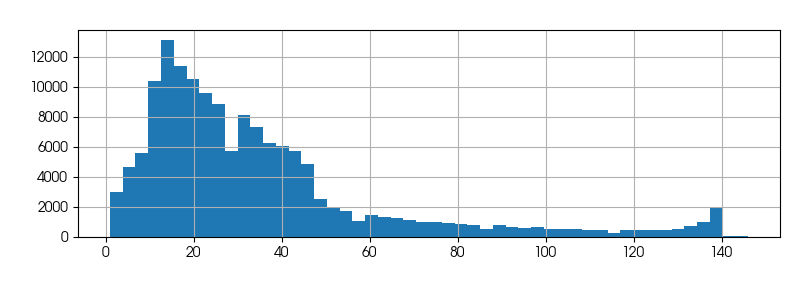


=== 전처리 후 예시 ===
0                                    아 더빙 진짜 짜증나네요 목소리
1                           흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나
2                                    너무재밓었다그래서보는것을추천한다
3                            교도소 이야기구먼 솔직히 재미는 없다평점 조정
4    사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...
Name: document, dtype: object


In [26]:
# 라이브러리 임포트
import pandas as pd  #CSV 파일 읽기, 데이터 프레임 조작
import numpy as np   #수치연산(평균, 분위수 등)
import torch         #딥러닝 텐서 연산
import torch.nn as nn # 신경망 레이어(LSTM, Linear 등)
from torch.nn.utils.rnn import pad_sequence #길이가 다른 시퀀스를 동일 길이로 맞춰주는 함수
from torch.utils.data import Dataset, DataLoader 
import sentencepiece as spm   #서브워드 토크나이저
import urllib.request         #URL에서 파일 다운로드
import tempfile, os, re       #임시파일 생성, 파일경로, 정규식
import matplotlib.pyplot as plt #그래프 그리기
import matplotlib
matplotlib.rcParams['font.family'] = "URW Gothic"  # 한글 폰트 설정

# 데이터 다운로드 
# 네이버 영화리뷰 감정분석 데이터셋 (NSMC)
# 구성: id | document(리뷰 텍스트) | label(0=부정, 1=긍정)
# 훈련: 150,000개 / 테스트: 50,000개
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    filename="ratings_train.txt"
)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
    filename="ratings_test.txt"
)

train_df = pd.read_csv('ratings_train.txt', sep='\t').dropna() #sep='\t' : 컬럼 구분자가 탭(\t)인 파일 읽기
test_df  = pd.read_csv('ratings_test.txt',  sep='\t').dropna()

# 코퍼스 기본 분석 
print("=== 데이터셋 기본 정보 ===")
print(f"훈련 데이터: {len(train_df):,}개 | 테스트 데이터: {len(test_df):,}개")
# 긍/부정 비율이 균등한지 -> 불균형이면 accurracy 지표가 왜곡될 수 있
print(f"긍/부정 비율 (train): {train_df['label'].value_counts().to_dict()}")
print(train_df.head())

# 문장 길이 분포 분석
# 길이 분포를 분석하는 이유:
#   1) max_len(패딩 기준 길이) 결정에 활용
#      → 너무 짧으면 정보 손실, 너무 길면 메모리 낭비
#   2) 이상치(비정상적으로 긴 리뷰) 파악
train_df['length'] = train_df['document'].apply(lambda x: len(str(x))) #lambda x: len(str(x)) : 각 문장을 문자열로 변환 후 길이 측정
print(f"\n평균 문장 길이: {train_df['length'].mean():.1f}자")
print(f"최대 문장 길이: {train_df['length'].max()}자")
# 75% 분위 : 전체 문장의 75%가 이 길이 이하
print(f"75% 분위 길이: {train_df['length'].quantile(0.75):.0f}자")

# 히스토그램으로 길이 분포 시각화
plt.figure(figsize=(8, 3))
train_df['length'].hist(bins=50) # 막대 50개로 분포 표현
plt.title('문장 길이 분포')
plt.xlabel('문자 수')
plt.ylabel('빈도')
plt.tight_layout() # 레이블이 잘리지 않도록 여백 조정
plt.show()

# 전처리: 특수문자 제거 
def clean_text(text):
        """
    텍스트에서 불필요한 특수문자 제거

    처리 내용:
        - 유지: 한글(가-힣), 영문(a-z, A-Z), 숫자(0-9), 공백(\s)
        - 제거: 그 외 모든 문자 (!, ?, ., #, @, ㅋㅋ 등)

    특수문자를 제거하는 이유:
        - 토크나이저가 의미 없는 특수문자에 vocab을 낭비하는 것 방지
        - 노이즈 감소 → 모델이 핵심 의미에 집중

    Args:
        text: 원본 리뷰 문자열
    Returns:
        정제된 문자열. 정제 후 빈 문장이면 '없음' 반환
        ('없음'으로 대체하는 이유: 빈 문자열은 토크나이징 시 빈 텐서가 되어
         pad_sequence에서 오류 발생)
    """
    # re.sub(패턴, 대체문자, 대상문자열)
    # [^가-힣a-zA-Z0-9\s] : 해당 문자 집합에 속하지 않는 모든 문자
    # ''로 대체 = 제거
    # 한글, 영문, 숫자, 공백만 유지
    text = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', str(text))
    text = text.strip()
    return text if text else '없음'  # 빈 문장 방지

train_df['document'] = train_df['document'].apply(clean_text)
test_df['document']  = test_df['document'].apply(clean_text)

print("\n=== 전처리 후 예시 ===")
print(train_df['document'].head())

2.sentencepiece 학습 및 토크나이저 구현

In [27]:
# corpus 파일 저장 
# SentencePieceTrainer.Train()은 파일 경로를 입력으로 받기 때문에
# 메모리에 있는 corpus 리스트를 텍스트 파일로 먼저 저장해야 함
corpus = train_df['document'].tolist()
# NamedTemporaryFile: 이름이 있는 임시 파일 생성
# mode='w'       : 텍스트 쓰기 모드
# suffix='.txt'  : 파일 확장자 지정 (SentencePiece가 텍스트 파일 요구)
# delete=False   : 파일 닫아도 자동 삭제 안 함 (Train()에서 경로로 접근해야 하므로)
# encoding='utf-8': 한글 인코딩

temp_file = tempfile.NamedTemporaryFile(
    mode='w', suffix='.txt', delete=False, encoding='utf-8'
)
for row in corpus:
    # strip()     : 문장 앞뒤 공백 제거
    # + '\n'      : 한 줄에 한 문장 형식으로 저장
    # SentencePiece는 줄바꿈(\n)으로 문장을 구분함
    temp_file.write(row.strip() + '\n')
temp_file.close()
print(f"임시 corpus 파일 저장 완료: {temp_file.name}")

# SentencePiece 모델 학습 (model_type / vocab_size 조합) 
# 다각도 성능 비교를 위해 model_type과 vocab_size를 달리하여 4가지 모델 학습
#
# [model_type]
#   unigram : 확률 기반. 여러 분할 후보 중 가장 확률 높은 분할 선택 (기본값)
#             예) '재밌었어요' → ['재밌', '었어요'] or ['재밌었', '어요'] 중 선택
#   bpe     : Byte Pair Encoding. 가장 자주 등장하는 문자 쌍을 반복 병합
#             예) 'a','b'가 자주 붙으면 'ab'를 하나의 토큰으로 합침
#             결과가 항상 동일한 결정적(deterministic) 방식
#
# [vocab_size]
#   4000 : 어휘 수 적음 → 하나의 토큰이 더 많은 문자를 담당 → OOV 위험 낮음
#   8000 : 어휘 수 많음 → 더 세밀한 분할 가능 → 표현력 높음
#          단, 학습 데이터가 충분해야 효과적
# 루브릭 ③: 다각도 비교를 위해 여러 옵션으로 학습
SP_CONFIGS = [
    {'model_type': 'unigram', 'vocab_size': 4000},
    {'model_type': 'unigram', 'vocab_size': 8000},
    {'model_type': 'bpe',     'vocab_size': 4000},
    {'model_type': 'bpe',     'vocab_size': 8000},
]

for cfg in SP_CONFIGS:
    # 저장될 모델 파일명 prefix
    # 예) nsmc_spm_bpe_v8000.model / nsmc_spm_bpe_v8000.vocab
    model_prefix = f"nsmc_spm_{cfg['model_type']}_v{cfg['vocab_size']}"
    spm.SentencePieceTrainer.Train(
        f"--input={temp_file.name} "          # 학습할 corpus 파일 경로
        f"--model_prefix={model_prefix} "     # 저장 파일명 (.model, .vocab 두 파일 생성)
        f"--vocab_size={cfg['vocab_size']} "  # 어휘 사전 크기
        f"--model_type={cfg['model_type']} "  # unigram 또는 bpe
        f"--pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3 "
        f"--character_coverage=0.9995"  # 한국어 대응
        # 전체 문자 중 vocab에 포함할 비율
        # 한국어는 문자 조합이 많으므로 0.9995 권장
        # 영어처럼 알파벳이 적은 언어는 1.0 사용
    )
    print(f"학습 완료: {model_prefix}")

# sp_tokenize() 구현 
def sp_tokenize(sp_model, corpus, max_len=64):
    """
    SentencePiece로 corpus를 토크나이징
    Args:
        sp_model : 로드된 SentencePieceProcessor
        corpus   : 문장 리스트
        max_len  : 최대 시퀀스 길이 (초과 시 자름)
    Returns:
        tensor     : 패딩된 텐서 shape (N, max_len)
        word_index : 단어 → 인덱스
        index_word : 인덱스 → 단어
    """
   # STEP 1: 문장 → 토큰 ID 시퀀스 변환
    tensors = []
    for sen in corpus:
        # EncodeAsIds(): 문장을 서브워드 ID 정수 리스트로 변환
        # str()로 감싸는 이유: 숫자나 기타 타입이 섞인 경우 오류 방지
        # [:max_len]: 지정된 최대 길이 이후 토큰은 버림
        ids = sp_model.EncodeAsIds(str(sen))[:max_len]  # 최대 길이 제한
        tensors.append(torch.tensor(ids, dtype=torch.long)) # dtype=torch.long: nn.Embedding 입력 타입 요구사항 (정수형)

   # STEP 2: vocab 사전 구축
   # GetPieceSize(): 모델의 전체 vocab 크기 반환 (vocab_size와 동일)
   # IdToPiece(idx): 해당 ID에 대응하는 서브워드 문자열 반환
   # 예) 0 → '<pad>', 1 → '<unk>', 500 → '▁영화'
   # ▁(언더바): 단어 시작을 나타내는 SentencePiece 특수 기호
   #            공백 뒤에 오는 서브워드에 자동으로 붙음
    word_index, index_word = {}, {}
    for idx in range(sp_model.GetPieceSize()):
        word = sp_model.IdToPiece(idx)
        word_index[word] = idx
        index_word[idx]  = word

   # STEP 3: 가변 길이 시퀀스 패딩
   # 배치 내 문장들은 길이가 제각각 → 동일 길이로 맞춰야 텐서로 묶을 수 있음
   # pad_sequence: 가장 긴 시퀀스 기준으로 나머지를 padding_value로 채움
   # batch_first=True  → 출력 shape: (문장 수 N, 최대 길이 L)
   # batch_first=False → 출력 shape: (최대 길이 L, 문장 수 N)
   # padding_value=0   → <pad> 토큰 ID와 동일 (pad_id=0으로 학습했으므로)
    tensor = pad_sequence(tensors, batch_first=True, padding_value=0)

    return tensor, word_index, index_word

# 토크나이저 동작 확인 
# 학습된 모델 중 하나를 로드하여 실제 동작 검증
sp_test = spm.SentencePieceProcessor()
sp_test.Load('nsmc_spm_bpe_v8000.model')

sample = '영화 너무 재밌었어요 강추합니다'
print("\n=== 토크나이저 동작 확인 ===")
print(f"원문    : {sample}")
# EncodeAsPieces(): 문장을 서브워드 문자열 리스트로 변환 (사람이 읽을 수 있는 형태)
# ▁가 붙은 piece는 해당 위치가 단어의 시작임을 의미
print(f"Pieces  : {sp_test.EncodeAsPieces(sample)}") # EncodeAsIds(): 문장을 정수 ID 리스트로 변환 (모델 실제 입력값)
print(f"IDs     : {sp_test.EncodeAsIds(sample)}")
# Decode(): ID 리스트 → 원래 문장으로 복원
# ▁를 공백으로 변환하여 자연스러운 문장 재구성
# 완벽한 복원이 보장됨 (손실 없는 인코딩)
print(f"복원    : {sp_test.Decode(sp_test.EncodeAsIds(sample))}")

임시 corpus 파일 저장 완료: /tmp/tmptekkltmn.txt
학습 완료: nsmc_spm_unigram_v4000


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=/tmp/tmptekkltmn.txt --model_prefix=nsmc_spm_unigram_v4000 --vocab_size=4000 --model_type=unigram --pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3 --character_coverage=0.9995
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /tmp/tmptekkltmn.txt
  input_format: 
  model_prefix: nsmc_spm_unigram_v4000
  model_type: UNIGRAM
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corp

학습 완료: nsmc_spm_unigram_v8000
학습 완료: nsmc_spm_bpe_v4000
학습 완료: nsmc_spm_bpe_v8000

=== 토크나이저 동작 확인 ===
원문    : 영화 너무 재밌었어요 강추합니다
Pieces  : ['▁영화', '▁너무', '▁재밌었어요', '▁강추', '합니다']
IDs     : [5, 21, 2117, 969, 244]
복원    : 영화 너무 재밌었어요 강추합니다


face.cc(411) LOG(INFO) Loaded all 149995 sentences
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: <pad>
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: <unk>
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: <s>
trainer_interface.cc(427) LOG(INFO) Adding meta_piece: </s>
trainer_interface.cc(432) LOG(INFO) Normalizing sentences...
trainer_interface.cc(541) LOG(INFO) all chars count=4981067
trainer_interface.cc(552) LOG(INFO) Done: 99.95% characters are covered.
trainer_interface.cc(562) LOG(INFO) Alphabet size=1575
trainer_interface.cc(563) LOG(INFO) Final character coverage=0.9995
trainer_interface.cc(594) LOG(INFO) Done! preprocessed 149995 sentences.
unigram_model_trainer.cc(265) LOG(INFO) Making suffix array...
unigram_model_trainer.cc(269) LOG(INFO) Extracting frequent sub strings... node_num=1713235
unigram_model_trainer.cc(312) LOG(INFO) Initialized 310147 seed sentencepieces
trainer_interface.cc(600) LOG(INFO) Tokenizing input sentences with whitespace: 1499

3. RNN 분류 모델 정의 및 학습

In [28]:
# ── Dataset 정의 ─────────────────────────────────────────────
class NSMCDataset(Dataset):
    def __init__(self, tensors, labels):
        self.tensors = tensors
        self.labels  = torch.tensor(labels, dtype=torch.float)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.tensors[idx], self.labels[idx]


# ── Bidirectional LSTM 분류 모델 ─────────────────────────────
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 n_layers=2, dropout=0.3):
        super().__init__()
        # 임베딩: 토큰 ID → 벡터 (padding_idx=0 은 학습 제외)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # 양방향 LSTM: 문맥을 양쪽 방향으로 학습
        self.rnn = nn.LSTM(embed_dim, hidden_dim,
                           num_layers=n_layers,
                           batch_first=True,
                           dropout=dropout,
                           bidirectional=True)
        # 분류기: 양방향 hidden → 이진 출력
        self.fc      = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded        = self.dropout(self.embedding(x))   # (N, L, E)
        _, (hidden, _)  = self.rnn(embedded)                # hidden: (layers*2, N, H)
        # 마지막 레이어의 순방향·역방향 hidden 결합
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1) # (N, H*2)
        return self.fc(self.dropout(hidden)).squeeze(1)     # (N,)


# ── 학습 / 평가 함수 ─────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 기울기 폭발 방지
        optimizer.step()
        total_loss += loss.item()
        correct    += ((out > 0) == y.bool()).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            total_loss += loss.item()
            correct    += ((out > 0) == y.bool()).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)


# ── SentencePiece 전체 실험 실행 ─────────────────────────────
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS  = 5
results = {}  # 최종 성능 저장

for cfg in SP_CONFIGS:
    model_prefix = f"nsmc_spm_{cfg['model_type']}_v{cfg['vocab_size']}"
    label        = f"SP-{cfg['model_type']}-{cfg['vocab_size']}"
    print(f'\n{"="*50}')
    print(f'실험: {label}')
    print(f'{"="*50}')

    # 모델 로드 및 토크나이징
    sp = spm.SentencePieceProcessor()
    sp.Load(f'{model_prefix}.model')

    train_tensor, _, _ = sp_tokenize(sp, train_df['document'].tolist())
    test_tensor,  _, _ = sp_tokenize(sp, test_df['document'].tolist())

    train_loader = DataLoader(
        NSMCDataset(train_tensor, train_df['label'].tolist()),
        batch_size=64, shuffle=True
    )
    test_loader = DataLoader(
        NSMCDataset(test_tensor, test_df['label'].tolist()),
        batch_size=64
    )

    # 모델·옵티마이저·손실함수 초기화
    model     = RNNClassifier(vocab_size=sp.GetPieceSize()).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    best_acc = 0
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        best_acc = max(best_acc, te_acc)
        print(f'Epoch {epoch}/{EPOCHS} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
              f'Test  Loss: {te_loss:.4f} Acc: {te_acc:.4f}')

    results[label] = best_acc


실험: SP-unigram-4000
Epoch 1/5 | Train Loss: 0.4816 Acc: 0.7589 | Test  Loss: 0.3692 Acc: 0.8336
Epoch 2/5 | Train Loss: 0.3669 Acc: 0.8346 | Test  Loss: 0.3432 Acc: 0.8494
Epoch 3/5 | Train Loss: 0.3314 Acc: 0.8533 | Test  Loss: 0.3271 Acc: 0.8555
Epoch 4/5 | Train Loss: 0.3096 Acc: 0.8646 | Test  Loss: 0.3325 Acc: 0.8564
Epoch 5/5 | Train Loss: 0.2890 Acc: 0.8744 | Test  Loss: 0.3245 Acc: 0.8609

실험: SP-unigram-8000
Epoch 1/5 | Train Loss: 0.4982 Acc: 0.7459 | Test  Loss: 0.3756 Acc: 0.8288
Epoch 2/5 | Train Loss: 0.3632 Acc: 0.8366 | Test  Loss: 0.3384 Acc: 0.8517
Epoch 3/5 | Train Loss: 0.3247 Acc: 0.8583 | Test  Loss: 0.3326 Acc: 0.8543
Epoch 4/5 | Train Loss: 0.2990 Acc: 0.8700 | Test  Loss: 0.3293 Acc: 0.8602
Epoch 5/5 | Train Loss: 0.2787 Acc: 0.8807 | Test  Loss: 0.3288 Acc: 0.8621

실험: SP-bpe-4000
Epoch 1/5 | Train Loss: 0.4819 Acc: 0.7588 | Test  Loss: 0.3772 Acc: 0.8327
Epoch 2/5 | Train Loss: 0.3642 Acc: 0.8363 | Test  Loss: 0.3452 Acc: 0.8488
Epoch 3/5 | Train Loss: 0.331

4.konlpy 형태소 분석기 비교

In [32]:
!sudo apt-get update
!sudo apt-get install -y default-jdk

Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Get:2 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:5 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [3521 kB]
Get:6 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 Packages [2154 kB]
Get:7 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [1995 kB]
Fetched 8049 kB in 3s (2662 kB/s)  
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  adwaita-icon-theme at-spi2-common at-spi2-core bsdutils ca-certificates-java
  dbus dbus-bin dbus-daemon dbus-session-bus-common dbus-system-bus-common
  dbus-user-session dconf-gsettings-backend dconf-service default-jdk-headless
  default-jre

In [33]:
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'
os.environ['PATH'] = os.environ['JAVA_HOME'] + '/bin:' + os.environ['PATH']

!java -version  # 설치 확인

openjdk version "21.0.10" 2026-01-20
OpenJDK Runtime Environment (build 21.0.10+7-Ubuntu-124.04)
OpenJDK 64-Bit Server VM (build 21.0.10+7-Ubuntu-124.04, mixed mode, sharing)


In [35]:
from konlpy.tag import Okt

def konlpy_tokenize(tagger, corpus, max_len=64):
    """
    KoNLPy 형태소 분석기로 토크나이징

    Args:
        tagger  : KoNLPy 형태소 분석기 객체
        corpus  : 문장 리스트
        max_len : 최대 시퀀스 길이
    Returns:
        tensor     : 패딩된 텐서
        word_index : 단어 → 인덱스
        index_word : 인덱스 → 단어
    """
    # 1.형태소 분석 (시간이 오래 걸릴 수 있음)
    tokenized = [tagger.morphs(str(sen))[:max_len] for sen in corpus]

    # ② 단어 사전 구축 (0은 패딩 예약, 1부터 시작)
    word_index = {}
    for tokens in tokenized:
        for token in tokens:
            if token not in word_index:
                word_index[token] = len(word_index) + 1
    index_word = {v: k for k, v in word_index.items()}

    # 2.시퀀스 변환 및 패딩
    tensors = [
        torch.tensor([word_index.get(t, 0) for t in tokens], dtype=torch.long)
        for tokens in tokenized
    ]
    tensor = pad_sequence(tensors, batch_first=True, padding_value=0)

    return tensor, word_index, index_word


for tagger_name, tagger in [('Okt', Okt())]:
    label = f'KoNLPy-{tagger_name}'
    print(f'\n{"="*50}')
    print(f'실험: {label}')
    print(f'{"="*50}')

    train_tensor, w2i, _ = konlpy_tokenize(tagger, train_df['document'].tolist())
    test_tensor,  _,   _ = konlpy_tokenize(tagger, test_df['document'].tolist())

    train_loader = DataLoader(
        NSMCDataset(train_tensor, train_df['label'].tolist()),
        batch_size=64, shuffle=True
    )
    test_loader = DataLoader(
        NSMCDataset(test_tensor, test_df['label'].tolist()),
        batch_size=64
    )

    model     = RNNClassifier(vocab_size=len(w2i) + 1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    best_acc = 0
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        best_acc = max(best_acc, te_acc)
        print(f'Epoch {epoch}/{EPOCHS} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
              f'Test  Loss: {te_loss:.4f} Acc: {te_acc:.4f}')

    results[label] = best_acc


실험: KoNLPy-Okt
Epoch 1/5 | Train Loss: 0.4871 Acc: 0.7549 | Test  Loss: 0.9782 Acc: 0.4939
Epoch 2/5 | Train Loss: 0.3574 Acc: 0.8396 | Test  Loss: 1.1166 Acc: 0.5009
Epoch 3/5 | Train Loss: 0.3046 Acc: 0.8680 | Test  Loss: 1.0923 Acc: 0.5038
Epoch 4/5 | Train Loss: 0.2669 Acc: 0.8877 | Test  Loss: 1.3076 Acc: 0.5038
Epoch 5/5 | Train Loss: 0.2350 Acc: 0.9033 | Test  Loss: 1.3787 Acc: 0.5075


5. 다각도 성능 비교 분석


최종 성능 비교 (Test Accuracy)
SP-unigram-8000                | 0.8621 목표달성
                               | ###########################################
SP-bpe-8000                    | 0.8617 목표달성
                               | ###########################################
SP-unigram-4000                | 0.8609 목표달성
                               | ###########################################
SP-bpe-4000                    | 0.8608 목표달성
                               | ###########################################
KoNLPy-Okt                     | 0.5075 목표미달
                               | #########################


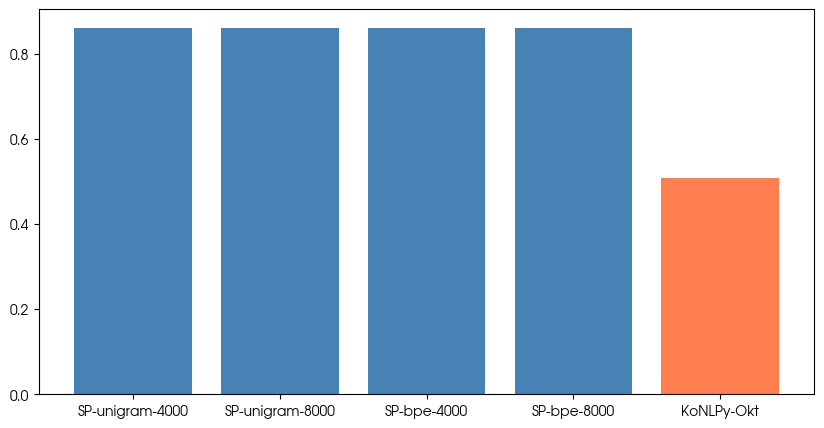

In [36]:
# 최종 결과 텍스트 출력
print('\n' + '='*50)
print('최종 성능 비교 (Test Accuracy)')
print('='*50)

# results 딕셔너리를 정확도 기준 내림차순 정렬하여 출력
# sorted()의 key=lambda x: -x[1] : 값(정확도)을 기준으로 내림차순 정렬
# -x[1] : 음수로 변환하여 내림차순 효과
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    # '#' * int(acc * 50) : 정확도를 시각적 막대로 표현
    # 예) acc=0.85 → '#' * 42 → '##########################################'
    # int()로 소수점 버림하여 정수 개수만큼 '#' 반복
    bar    = '#' * int(acc * 50)

    # 정확도 0.80 이상이면 목표달성, 미만이면 목표미달
    # 루브릭 기준: 80% 이상의 test accuracy 달성 여부 판단
    status = '목표달성' if acc >= 0.80 else '목표미달'

    # :30s : 왼쪽 정렬로 30칸 확보 (여러 모델명 길이가 달라도 정렬 유지)
    # .4f  : 소수점 4자리까지 출력
    print(f'{name:30s} | {acc:.4f} {status}')

    # 막대 출력 (모델명 칸과 동일한 너비로 맞춤)
    print(f'{"":30s} | {bar}')


# 시각화: 토크나이저별 성능 막대 그래프
plt.figure(figsize=(10, 5))  # 가로 10인치, 세로 5인치 크기의 그래프

names  = list(results.keys())    # 모델명 리스트 (x축 레이블)
accs   = list(results.values())  # 정확도 리스트 (y축 값)

# SentencePiece 모델은 파란색, KoNLPy 모델은 주황색으로 구분
# 'SP'가 이름에 포함되면 steelblue, 아니면 coral
colors = ['steelblue' if 'SP' in n else 'coral' for n in names]

# 막대 그래프 생성
# bars 변수에 저장하는 이유: 나중에 막대 위치를 계산하여 수치 표시할 때 사용
bars = plt.bar(names, accs, color=colors)

# 목표 정확도 80% 기준선 표시
# y=0.80        : 기준선

#### 회고
1. Kkma는 메모리를 많이 사용해서 오류 발생. 확인결과 Kkma는 정확도는 높지만 속도가 매우 느리고 메모리를 많이 사용하는 단점이 있어 실무에서도 대용량 데이터에는 잘 사용하지 않음을 확인

2. SentencePiece 분석
   1) vocab_size 영향 (4000 vs 8000) : unigram과 bpe 모두 vocab_size를 4000에서 8000으로 늘렸을 때 성능이 소폭 향상함을 확인
     - 향상폭이 매우 작은 이유는 네이버 영화 리뷰가 비교적 단순한 일상 어휘로 구성되어 있어 4,000개의 어휘만으로도 대부분의 표현을 커버할 수 있었을 것으로 예상됨
     - 더 복잡한 도메인(법률, 의학등)에서는 vocab_size의 영향이 더 크게 나타날 수도 있음        
   2) model_type 영향 (unigram vs bpe) : 동일한 vocab_size에서 unigram이 bpe보다 일관되게 근소하게 높은 성능을 보였음
     - 차이가 매우 작아 통계적으로 유의미하다고 보기 어렵다고 판단됨
     - 다만 unigram은 확률기반으로 여러 분할 후보 중 최적을 선택하는 방식이므로, 한국어처럼 형태 변화가 많은 언어에서 미세하게 유리할 수 있다고 생각함.
       
3.  KoNLPy-Okt 분석 (50.75%)
   1) KoNLPy-Okt가 50.75%라는 매우 낮은 성능을 보인 것은 모델 자체의 문제가 아니라 학습 과정의 문제일 가능성이 높습니다.
     - 원인 1 단어 사전 불일치 : train corpus로 구축한 word_index를 test corpus에 그대로 적용할 때, test에만 등장하는 형태소는 모두 0(패딩과 동일)으로 처리. 이 경우 모델이 의미 있는 패턴을 학습하지 못하고 랜덤 수준(50%)에 가까운 결과를 냄
     - 원인 2 형태소 분석 오류 누적 : Okt는 SNS 텍스트에 최적화되어 있지만, 오탈자나 신조어가 많은 영화 리뷰에서는 형태소 분석이 부정확해질 수 있음. 잘못 분석된 형태소가 대량으로 누적되면 모델이 올바른 패턴을 학습하기 어려움
     - 원인 3 학습률 또는 수렴 문제 : SentencePiece 모델과 동일한 하이퍼파라미터를 사용했지만, vocab 크기와 시퀀스 특성이 달라 최적 학습률이 다를 수 있음
      
4. SentencePiece vs KoNLPy 비교 결론
   1) 이번 실험에서 SentencePiece가 KoNLPy-Okt 대비 압도적으로 높은 성능을 보였음
   2) 다만 KoNLPy-Okt의 50.75%는 정상적인 성능이 아니므로, 위에서 언급한 원인들을 점검하고 재실험하면 실제 성능 차이는 더 작을 가능성이 있음.

5. 학습을 하면서 오늘은 파이썬에 대한 지식이 없음을 한탄하게 되는 순간이 굉장히 많았음. 파이썬 공부를 병행하면서 학습을 하는데 있어 몇배의 시간이 걸림에 너무 힘든 시간이였음.
      